In [ ]:

!pip install -U datasets -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.1 MB/s eta 0:00:00


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
num_workers = 2 if device.type == "cuda" else 0
pin_memory = device.type == "cuda"
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## Task 1: Load CIFAR-10 from Hugging Face

In [ ]:

ds = load_dataset("uoft-cs/cifar10")
train_ds = ds["train"]
test_ds = ds["test"]

classes = train_ds.features["label"].names
print("Train size:", len(train_ds))
print("Test size:", len(test_ds))
sample_pil = train_ds[0]["img"]
print("Image size (W,H):", sample_pil.size, "Mode:", sample_pil.mode)
print("Classes:", classes)


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train size: 50000
Test size: 10000
Image size (W,H): (32, 32) Mode: RGB
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


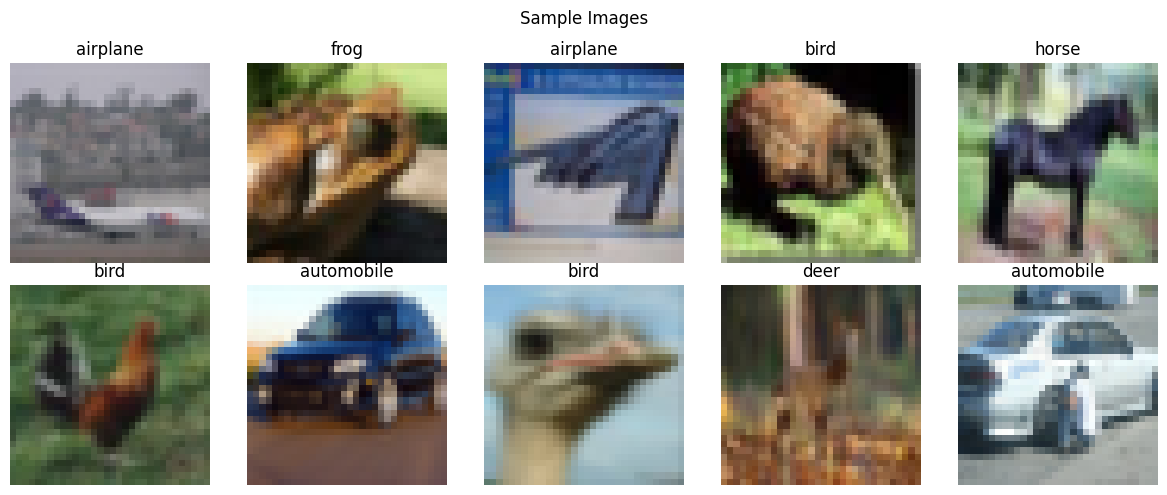

In [ ]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    item = train_ds[i]
    ax.imshow(item["img"])
    ax.set_title(classes[item["label"]])
    ax.axis("off")
plt.suptitle("Sample Images")
plt.tight_layout()
plt.show()


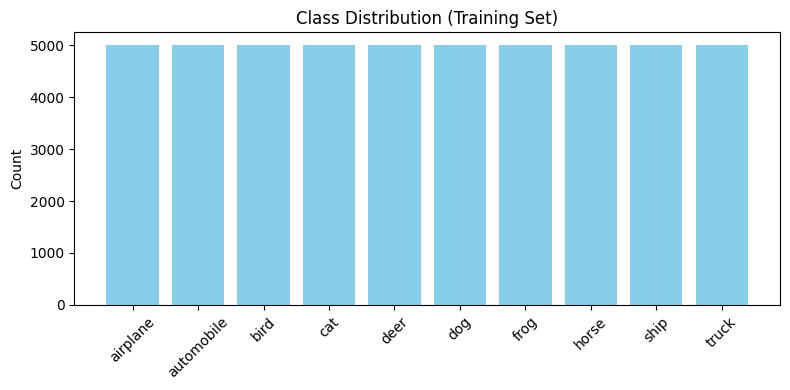

In [ ]:

labels = train_ds["label"]
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([classes[u] for u in unique], counts, color="skyblue")
plt.xticks(rotation=45)
plt.title("Class Distribution (Training Set)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Task 2: Convolution Layer - Kernel Size Comparison

In [ ]:

to_tensor = transforms.ToTensor()
sample_img = to_tensor(train_ds[0]["img"].convert("RGB")).unsqueeze(0)

for k in [3, 5, 7]:
    conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=k, stride=1, padding=0)
    out = conv(sample_img)
    print(f"Kernel {k}x{k} -> Feature map size: {tuple(out.shape)}")


Kernel 3x3 -> Feature map size: (1, 8, 30, 30)
Kernel 5x5 -> Feature map size: (1, 8, 28, 28)
Kernel 7x7 -> Feature map size: (1, 8, 26, 26)


## Task 3: Stride and Padding Study

In [ ]:

def conv_output_dim(in_dim, kernel, stride, padding):
    return (in_dim + 2 * padding - kernel) // stride + 1

configs = [
    {"kernel": 3, "stride": 1, "padding": 0, "label": "Stride=1"},
    {"kernel": 3, "stride": 2, "padding": 0, "label": "Stride=2"},
    {"kernel": 3, "stride": 1, "padding": 1, "label": "Padding=Same(1)"},
    {"kernel": 3, "stride": 1, "padding": 0, "label": "Padding=Valid(0)"},
]

for cfg in configs:
    conv = nn.Conv2d(3, 8, kernel_size=cfg["kernel"], stride=cfg["stride"], padding=cfg["padding"])
    out = conv(sample_img)
    computed = conv_output_dim(32, cfg["kernel"], cfg["stride"], cfg["padding"])
    print(f"{cfg['label']}: output shape {tuple(out.shape)}, computed dim {computed}x{computed}")


Stride=1: output shape (1, 8, 30, 30), computed dim 30x30
Stride=2: output shape (1, 8, 15, 15), computed dim 15x15
Padding=Same(1): output shape (1, 8, 32, 32), computed dim 32x32
Padding=Valid(0): output shape (1, 8, 30, 30), computed dim 30x30


## Task 4: Feature Map Visualization

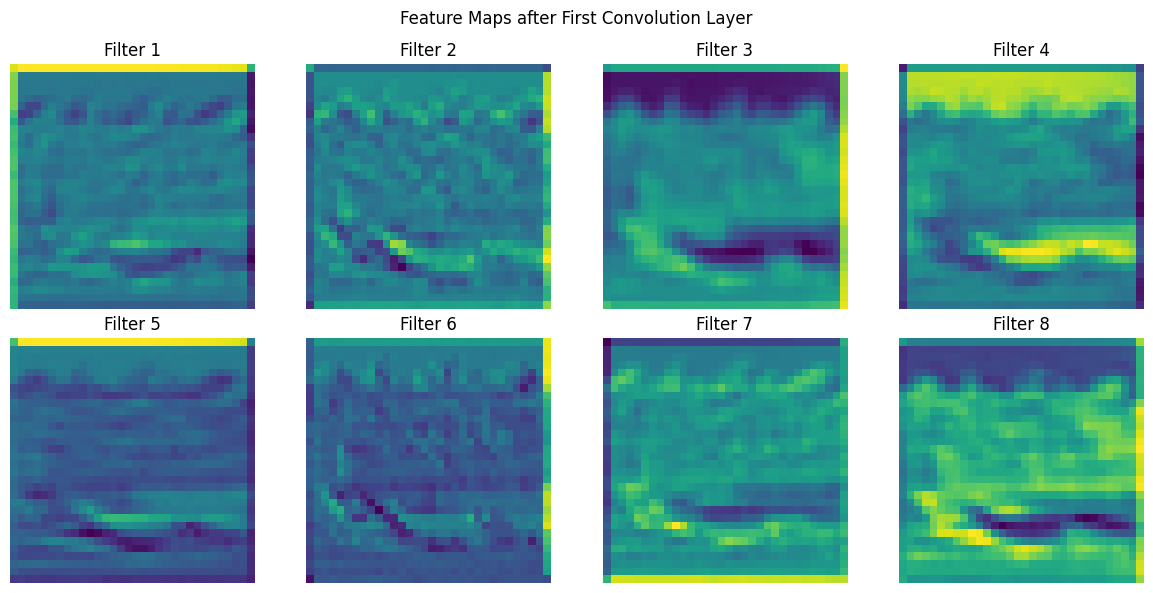

In [ ]:

first_conv = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
with torch.no_grad():
    fmap = first_conv(sample_img)
fmap = fmap.squeeze(0)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmap[i].detach().numpy(), cmap="viridis")
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")
plt.suptitle("Feature Maps after First Convolution Layer")
plt.tight_layout()
plt.show()


## Task 5: Pooling Strategy Comparison (Max vs Average)

In [ ]:

maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)

max_out = maxpool(fmap.unsqueeze(0))
avg_out = avgpool(fmap.unsqueeze(0))

print("Input shape:", fmap.unsqueeze(0).shape)
print("MaxPool output shape:", max_out.shape)
print("AvgPool output shape:", avg_out.shape)


Input shape: torch.Size([1, 16, 32, 32])
MaxPool output shape: torch.Size([1, 16, 16, 16])
AvgPool output shape: torch.Size([1, 16, 16, 16])


In [ ]:

class PoolCNN(nn.Module):
    def __init__(self, pool_type="max"):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) if pool_type == "max" else nn.AvgPool2d(2, 2)
        self.fc = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [ ]:

class CIFARDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.ds = hf_dataset
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["img"].convert("RGB")
        return self.transform(img), item["label"]

train_loader_small = DataLoader(CIFARDataset(train_ds), batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
test_loader_small = DataLoader(CIFARDataset(test_ds), batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

def quick_train_eval(model, loader, test_loader, epochs=3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            out = model(xb).argmax(1).cpu().numpy()
            preds.extend(out)
            trues.extend(yb.numpy())
    return accuracy_score(trues, preds)

max_model = PoolCNN("max")
avg_model = PoolCNN("avg")

max_acc = quick_train_eval(max_model, train_loader_small, test_loader_small)
avg_acc = quick_train_eval(avg_model, train_loader_small, test_loader_small)

print(f"MaxPooling accuracy: {max_acc:.4f}, output size after pooling: {max_out.shape}")
print(f"AvgPooling accuracy: {avg_acc:.4f}, output size after pooling: {avg_out.shape}")


MaxPooling accuracy: 0.6393, output size after pooling: torch.Size([1, 16, 16, 16])
AvgPooling accuracy: 0.5740, output size after pooling: torch.Size([1, 16, 16, 16])


## Task 6: Full CNN Architecture and Training

In [ ]:

full_train_ds = CIFARDataset(train_ds)
full_test_ds = CIFARDataset(test_ds)

train_loader = DataLoader(full_train_ds, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(full_test_ds, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)


In [ ]:

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64 * 8 * 8, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = CNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)
Total parameters: 60362
Trainable parameters: 60362


In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")


Epoch 1/20 - train_loss: 1.4443 - train_acc: 0.4878 - val_loss: 1.1997 - val_acc: 0.5832
Epoch 2/20 - train_loss: 1.1008 - train_acc: 0.6151 - val_loss: 1.0576 - val_acc: 0.6343
Epoch 3/20 - train_loss: 0.9743 - train_acc: 0.6638 - val_loss: 0.9772 - val_acc: 0.6607
Epoch 4/20 - train_loss: 0.8915 - train_acc: 0.6922 - val_loss: 0.9599 - val_acc: 0.6709
Epoch 5/20 - train_loss: 0.8343 - train_acc: 0.7113 - val_loss: 0.9127 - val_acc: 0.6883
Epoch 6/20 - train_loss: 0.7924 - train_acc: 0.7250 - val_loss: 0.9073 - val_acc: 0.6888
Epoch 7/20 - train_loss: 0.7577 - train_acc: 0.7367 - val_loss: 0.9492 - val_acc: 0.6808
Epoch 8/20 - train_loss: 0.7223 - train_acc: 0.7505 - val_loss: 0.9376 - val_acc: 0.6862
Epoch 9/20 - train_loss: 0.6941 - train_acc: 0.7587 - val_loss: 0.9397 - val_acc: 0.6836
Epoch 10/20 - train_loss: 0.6701 - train_acc: 0.7690 - val_loss: 0.9142 - val_acc: 0.6999
Epoch 11/20 - train_loss: 0.6417 - train_acc: 0.7764 - val_loss: 0.9078 - val_acc: 0.7093
Epoch 12/20 - train

## Task 7: Evaluation Metrics

In [ ]:

model.eval()
all_preds, all_trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        out = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(out)
        all_trues.extend(yb.numpy())

acc = accuracy_score(all_trues, all_preds)
prec = precision_score(all_trues, all_preds, average="macro")
rec = recall_score(all_trues, all_preds, average="macro")
f1 = f1_score(all_trues, all_preds, average="macro")

print("Test Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print()
print(classification_report(all_trues, all_preds, target_names=classes))


Test Accuracy: 0.695
Precision: 0.6970791505161575
Recall: 0.695
F1-score: 0.6938008959311365

              precision    recall  f1-score   support

    airplane       0.70      0.72      0.71      1000
  automobile       0.78      0.83      0.80      1000
        bird       0.59      0.61      0.60      1000
         cat       0.51      0.54      0.52      1000
        deer       0.75      0.56      0.64      1000
         dog       0.64      0.58      0.61      1000
        frog       0.74      0.78      0.76      1000
       horse       0.72      0.78      0.75      1000
        ship       0.74      0.83      0.78      1000
       truck       0.81      0.72      0.76      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



## Mandatory Plots

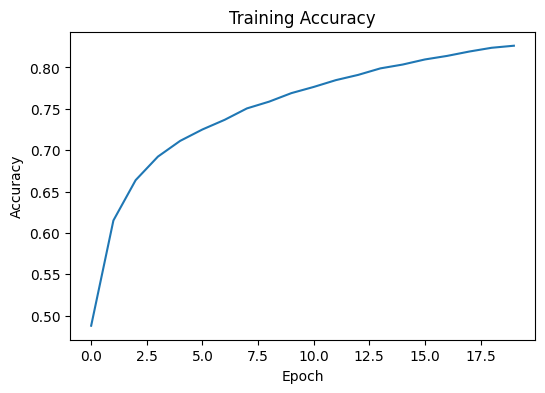

In [ ]:

plt.figure(figsize=(6, 4))
plt.plot(history["train_acc"])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


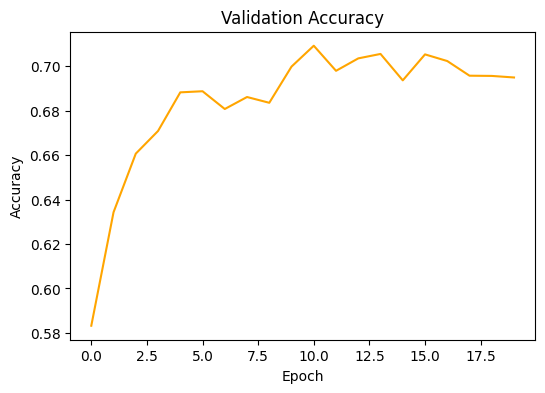

In [ ]:

plt.figure(figsize=(6, 4))
plt.plot(history["val_acc"], color="orange")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


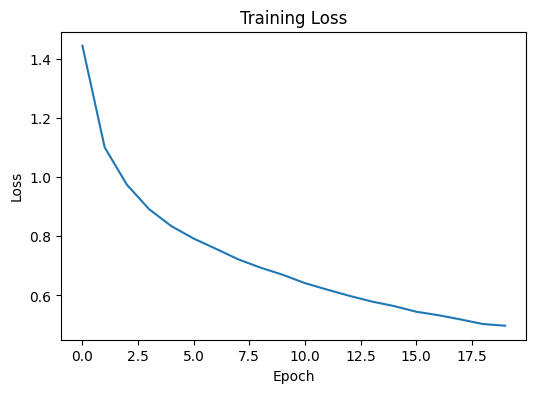

In [ ]:

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


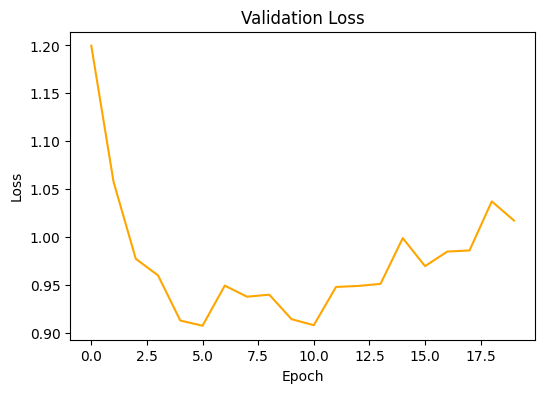

In [ ]:

plt.figure(figsize=(6, 4))
plt.plot(history["val_loss"], color="orange")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


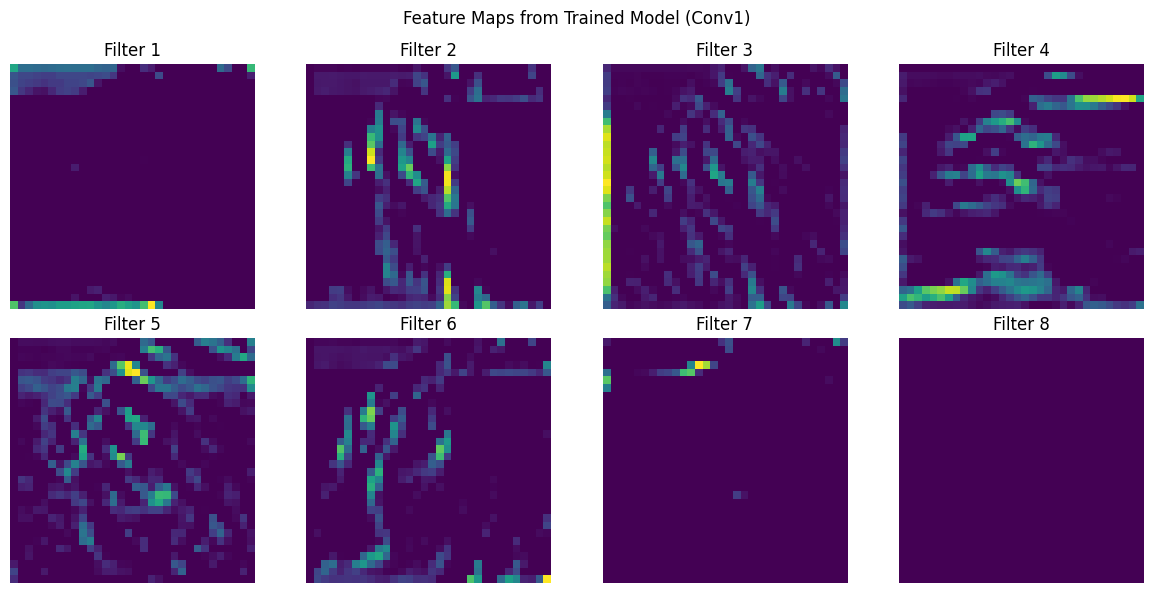

In [ ]:

with torch.no_grad():
    sample_batch = next(iter(train_loader))[0][:1].to(device)
    fmap2 = torch.relu(model.conv1(sample_batch)).squeeze(0).cpu()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmap2[i].numpy(), cmap="viridis")
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")
plt.suptitle("Feature Maps from Trained Model (Conv1)")
plt.tight_layout()
plt.show()


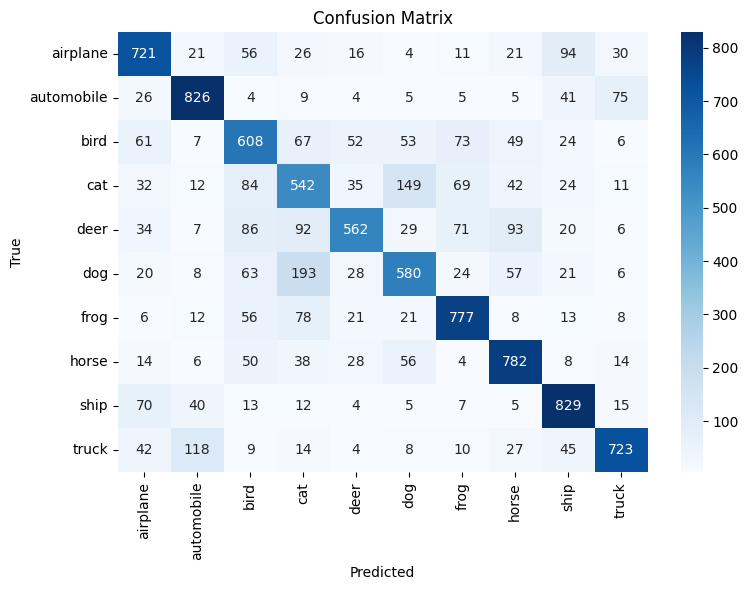

In [ ]:

cm = confusion_matrix(all_trues, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## Results Summary

In [ ]:

print("Training Accuracy:", history["train_acc"][-1])
print("Testing Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)


Training Accuracy: 0.82628
Testing Accuracy: 0.695
Precision: 0.6970791505161575
Recall: 0.695
F1-score: 0.6938008959311365
Total Parameters: 60362
Trainable Parameters: 60362
